In [4]:
import pandas as pd
import numpy as np
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from tqdm import tqdm
import multiprocessing as mp
import re
import pickle
from itertools import product

In [5]:
# Format plots
sns.set(style="white",
        font_scale=1.5,
        rc={'figure.figsize':(12,6)})

# Make directory for figures
if not os.path.isdir("./figures/"):
    os.mkdir("./figures/")

In [6]:
# Define the parameters
paramDic = {"rS":.027, "rR":.027, "cRS":1., "cSR":1.,"dD":1.5, 
            "k":1., "D":0, "theta":1, 'DMax':1.}
paramDic['dR'] = 0.2*paramDic['rR']
paramDic['dS'] = 0.2*paramDic['rS']
nTimePts = 100
intervalLength = 1

def GenerateParameterDic(initialPestBurden,resistantFraction,cost,turnover,paramDic):
    """
    Generate parameter dictionary for given initial conditions, cost and turnover values.
    :param cost:
    :param turnover:
    :param paramDic:
    :return:
    """
    # Generate ICS
    initialStateVec = [initialPestBurden * (1 - resistantFraction), initialPestBurden * resistantFraction, 0, paramDic['DMax']]
    initialStateVec[2] = paramDic['theta'] * (initialStateVec[0] + initialStateVec[1])

    # Generate params
    paramDic = paramDic.copy()
    paramDic['cSR'] = (1+cost)*paramDic['cSR']
    paramDic['dR'] = turnover*paramDic['rS']
    paramDic['dS'] = turnover*paramDic['rS']
    return initialStateVec,paramDic




In [7]:
def lotka_volterra(t, uVec, paramDic):
    s, r, v, c = uVec
    dudtVec = np.zeros_like(uVec)
    dudtVec[0] = paramDic['rS']*(1 - (s + paramDic['cRS'] * r)/paramDic['k']) * (1-paramDic['dD']*c) * s - paramDic['dS']*s
    dudtVec[1] = paramDic['rR']*(1 - (r + paramDic['cSR'] * s)/paramDic['k'])*r - paramDic['dR']*r
    dudtVec[2] = paramDic['theta']*(dudtVec[0] + dudtVec[1])
    dudtVec[3] = 0
    return (dudtVec)

In [8]:
# --------------------------- Simulation -----------------------------------------------------
def Simulate_pesticide_max(initialStateVec,paramDic,modelFun,t_end=None,t_span=None,t_eval=None,nTimePts=100,**kwargs):
    t_span = t_span if t_span is not None else (0, t_end)
    t_eval = t_eval if t_eval is not None else np.linspace(t_span[0],t_span[1],nTimePts)
    solObj = scipy.integrate.solve_ivp(lambda t, uVec: modelFun(t,uVec,paramDic), y0=initialStateVec,
                                       t_span=t_span,t_eval=t_eval,**kwargs)
    return pd.DataFrame({"Time": solObj.t, "S": solObj.y[0, :], "R": solObj.y[1, :],
                              "V":solObj.y[2,:], "D": solObj.y[3, :]})

def Simulate_non_int_fixed_target(initialStateVec,paramDic,modelFun,
                               atThreshold=0.5,intervalLength=3,refSize=None,t_end=None,t_span=None,t_eval=None,nTimePts=100,**kwargs):
    t_span = t_span if t_span is not None else (0, t_end)
    t_eval = t_eval if t_eval is not None else np.linspace(0,t_end,nTimePts)
    resultsDFList = []
    currInterval = [t_span[0],t_span[0]+intervalLength]
    refSize = initialStateVec[2] if refSize is None else refSize
    pesticideDose = initialStateVec[-1]
    currCycleId = 0
    while currInterval[1] <= t_end: 
        # Simulate
        resultsDf = Simulate_pesticide_max(initialStateVec,modelFun=modelFun,
                                         paramDic=paramDic,
                                         t_span=(currInterval[0], currInterval[1]),
                                         t_eval=np.linspace(currInterval[0], currInterval[1],1000))
        resultsDf['CycleId'] = currCycleId
        resultsDFList.append(resultsDf)

        # Update pesticide dose
        if resultsDf.V.iat[-1] > refSize:
            currCycleId += (pesticideDose==0)
            pesticideDose = paramDic['DMax']
        elif resultsDf.V.iat[-1] < (1-atThreshold)*refSize:
            pesticideDose = 0
        else:
            pesticideDose = (pesticideDose > 0)*paramDic['DMax']
        initialStateVec = [resultsDf.S.iat[-1], resultsDf.R.iat[-1], resultsDf.V.iat[-1], pesticideDose]

        # Update interval
        currInterval = [x+intervalLength for x in currInterval]
    resultsDf = pd.concat(resultsDFList)
    # Interpolate to the desired time grid
    trimmedResultsDic = {'Time':t_eval}
    for variable in ['S','R','V','D','CycleId']:
        f =  scipy.interpolate.interp1d(resultsDf.Time,resultsDf[variable],fill_value="extrapolate")
        trimmedResultsDic = {**trimmedResultsDic,variable:f(t_eval)}
    return pd.DataFrame(data=trimmedResultsDic)

In [9]:
def ProfileTreatmentStrategies(modelFun,paramDic,atThresholdList=[0.3, 0.5],intervalLength=0.3,dt=1.,
                               initialBurdenList=np.linspace(0.25,0.75,5),
                               resistantFractionList=[0.1,0.01,0.001],
                               burdenThresholdMultiplier=1.2,cureThreshold=0.1,enableProgressBar=True):
    tmpDicList = []
    for initialPestBurden,resistantFraction in tqdm([(x,y) for x in initialBurdenList for y in resistantFractionList],disable=enableProgressBar==False):
        initialStateVec,_ = GenerateParameterDic(initialPestBurden=initialPestBurden,resistantFraction=resistantFraction,cost=0,turnover=0,paramDic=paramDic)
        maxTolerableBurden = initialPestBurden*burdenThresholdMultiplier
        burdenWhenControlled = cureThreshold*initialPestBurden

        # 0. Check that burden can progress
        rMax = np.inf
        if modelFun.__name__=='lotka_volterra':
            rMax = (1-paramDic['dR']/paramDic['rR'])*paramDic['k']
        if rMax < maxTolerableBurden:
            for strategy in ["MTD"]+[str(thresh) for thresh in atThresholdList]:
                tmpDicList.append({"TreatmentBranch": strategy,
                                   "ResistantFraction": resistantFraction, "InitialPestBurden": initialPestBurden,
                                   "Cured": False, "IndefiniteControl":True, "TimeToFailure": np.nan, "RelTimeGained": np.nan,
                                   "NCycles": np.nan})
            continue

        # 1. Simulate MTD until control or failure
        r0 = max(initialStateVec[1],0.001) # Ensure minimum resistant seed for stable estimate
        rR = paramDic.get('rR',paramDic.get('p',0.03))
        t_end = np.log((1-r0)/(r0*(1/maxTolerableBurden-1)))/rR
        finalBurden = 0
        cured = False
        currStateVec = initialStateVec
        currTime = 0
        # a) Figure out how long to simulate for. If MTD controls burden, skip this scenario.
        while finalBurden<maxTolerableBurden-1e-6 and not cured: # 1e-6 handles near-threshold numerical error
            resultsDf = Simulate_pesticide_max(initialStateVec=currStateVec,
                                             modelFun=modelFun,paramDic=paramDic,
                                             t_span=(currTime,t_end))
            finalBurden = resultsDf.V.iloc[-1]
            cured = np.any(resultsDf.V<burdenWhenControlled)
            currStateVec = [resultsDf.S.iloc[-1], resultsDf.R.iloc[-1], resultsDf.V.iloc[-1], 1]
            currTime = t_end
            t_end *= 1.1

        # Don't simulate if MTD controls burden
        if cured:
            tmpDicList.append({"TreatmentBranch":"MTD",
                               "ResistantFraction": resistantFraction, "InitialPestBurden":initialPestBurden,
                               "Cured":True, "IndefiniteControl":False, "TimeToFailure":np.nan,"RelTimeGained":np.nan,
                               "NCycles":np.nan})
            continue

        # b) Get the estimate for TTP using the same function and time grid used for AT.
        resultsDf = Simulate_non_int_fixed_target(initialStateVec,modelFun=modelFun,
                                               paramDic=paramDic,
                                               atThreshold=1.,
                                               refSize=initialPestBurden,
                                               intervalLength=intervalLength,
                                               t_eval=np.arange(0,t_end+dt,dt),
                                               t_end=t_end)
        timeToFailure_MTD = resultsDf.Time[resultsDf.V>maxTolerableBurden-1e-6].min() # robust near threshold
        tmpDicList.append({"TreatmentBranch":"MTD", "ResistantFraction": resistantFraction, "InitialPestBurden":initialPestBurden,
                            "Cured":False, "IndefiniteControl":False, "TimeToFailure":timeToFailure_MTD,"RelTimeGained":np.nan,
                           "NCycles":np.nan})

        # 2. Simulate AT
        for atThreshold in atThresholdList:
            t_end = 2*timeToFailure_MTD
            timeToFailure = np.nan
            while np.isnan(timeToFailure):
                resultsDf = Simulate_non_int_fixed_target(initialStateVec,modelFun=modelFun,
                                                       paramDic=paramDic,
                                                       atThreshold=atThreshold,
                                                       intervalLength=intervalLength,
                                                       t_eval=np.arange(0,t_end+dt,dt),
                                                       t_end=t_end)
                timeToFailure = resultsDf.Time[resultsDf.V>maxTolerableBurden-1e-6].min()
                t_end *= 1.1
            # Assess Performance
            relTimeGained = (timeToFailure-timeToFailure_MTD)/timeToFailure_MTD*100
            tmpDicList.append({"TreatmentBranch":str(atThreshold),
                               "ResistantFraction": resistantFraction, "InitialPestBurden":initialPestBurden,
                               "Cured":False, "IndefiniteControl":False, "TimeToFailure":timeToFailure,
                               "AbsTimeGained":timeToFailure-timeToFailure_MTD,"RelTimeGained":relTimeGained,
                               "NCycles":resultsDf.CycleId.max()})
    return pd.DataFrame(tmpDicList)


In [15]:
import numpy as np
import pandas as pd
import sys
from itertools import product
from tqdm import tqdm
import multiprocessing as mp

# Parameterise script
intervalLength = 1.
atThreshold = 0.5
turnoverList = [0.1] #np.linspace(0.15, 0.2,2)
costList = np.linspace(0.05,0.5,10)
nProcesses = 4
# ------------------------ Functions ------------------------
def ProfileParamSet(paramSet):
    turnover,cost = paramSet
    paramDic = {"rS": .027, "rR": .027, "cRS": 1., "cSR": 1., "dD": 1.5,
                "k": 1., "D": 0, "theta": 1, 'DMax': 1.}
    # Set up the parameters
    _, currParamDic = GenerateParameterDic(initialPestBurden=0, resistantFraction=0,
                                           cost=cost, turnover=turnover,
                                           paramDic=paramDic)
    print(cost,turnover)
    # Perform the comparison
    txComparisonDf = ProfileTreatmentStrategies(modelFun=lotka_volterra,paramDic=currParamDic,
                                                enableProgressBar=False,
                                                atThresholdList=[atThreshold],intervalLength=intervalLength,
                                                initialBurdenList=[0.4],
                                                resistantFractionList=np.linspace(0.001,0.01,10),
                                                burdenThresholdMultiplier=1.2,cureThreshold=1e-7)

    # Save results
    txComparisonDf['Turnover'] = turnover
    txComparisonDf['CompetitionCoefficient'] = cost
    return txComparisonDf

# ------------------------ Main ------------------------
pool = mp.Pool(processes=nProcesses,maxtasksperchild=1)
jobList = list(product(turnoverList, costList))
tmpDicList = list(tqdm(pool.imap(ProfileParamSet,jobList),total=len(jobList)))
resultsDf = pd.concat(tmpDicList,sort=True)
resultsDf.to_csv("ttpAnalysis_costTurnoverSweep.csv")

  0%|          | 0/10 [00:00<?, ?it/s]

0.050.10.150000000000000020.2    0.10.10.1
0.1


0.25 0.1
0.3 0.1

 10%|█         | 1/10 [00:12<01:49, 12.13s/it]


0.35000000000000003 0.1
0.4 0.1


 50%|█████     | 5/10 [00:22<00:20,  4.10s/it]

0.45 0.1


 60%|██████    | 6/10 [00:23<00:13,  3.26s/it]

0.5 0.1


100%|██████████| 10/10 [00:32<00:00,  3.27s/it]


In [16]:
txComparisonDf = pd.read_csv("ttpAnalysis_costTurnoverSweep.csv",index_col=0)

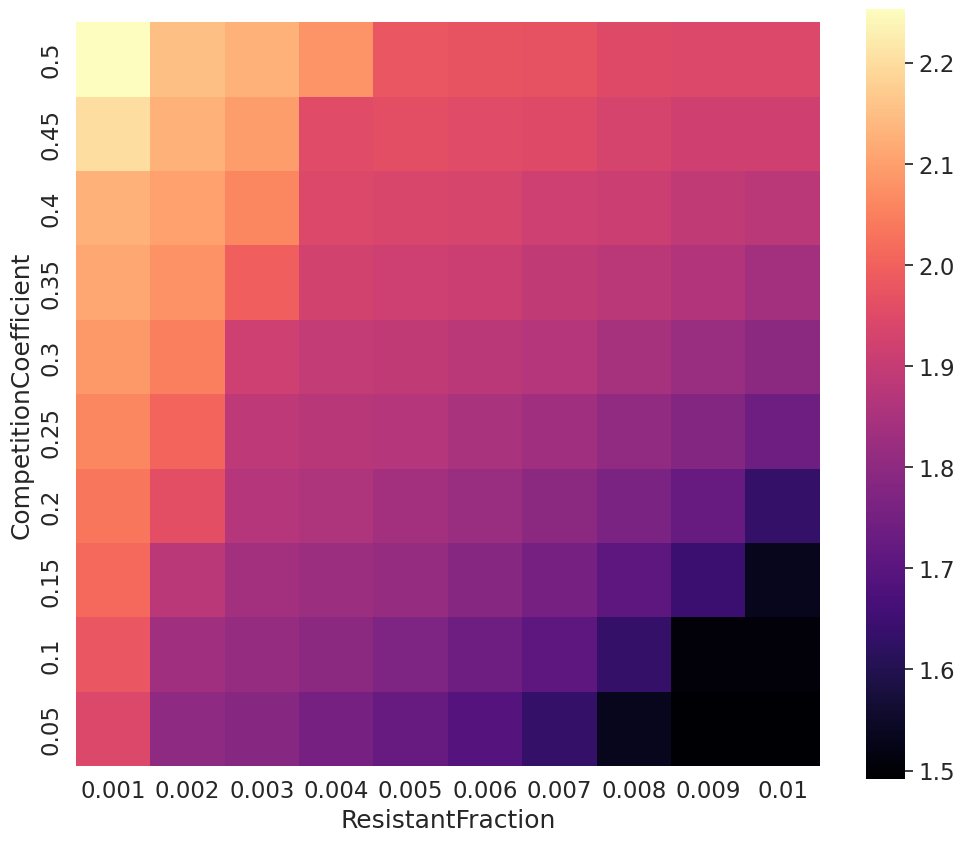

In [17]:
# Reshape into a matrix
tmpDf = txComparisonDf.loc[txComparisonDf.TreatmentBranch=="0.5",["CompetitionCoefficient","ResistantFraction","AbsTimeGained"]].reset_index(drop=True)
tmpDf['CompetitionCoefficient'] *= 1
tmpDf['ResistantFraction'] *= 1
tmpDf['AbsTimeGained'] = np.log10(tmpDf['AbsTimeGained'])
#tmpDf.sortlevel(["CompetitionCoefficient"], ascending=[False], sort_remaining=False)
timeToFailureMat = tmpDf.pivot(index="CompetitionCoefficient", columns="ResistantFraction", values="AbsTimeGained")
timeToFailureMat.sort_index(level="CompetitionCoefficient",ascending=False,inplace=True)


# Plot
fig, ax = plt.subplots(1,1,figsize=(12,10))
#ax.contourf(tmpDf.Cost.unique(),tmpDf.ResistantFraction.unique(),timeToFailureMat,10,cmap=sns.cubehelix_palette(light=1, as_cmap=True))
#contours = ax.contour(tmpDf.Cost.unique(),tmpDf.ResistantFraction.unique(),timeToFailureMat, 10, colors='black');
#plt.gca().set_facecolor('xkcd:light grey')
#plt.clabel(contours, inline=True, fontsize=28, fmt='%1.1f', rightside_up=True, )
g = sns.heatmap(data=timeToFailureMat,cmap='magma',square=True,cbar=True,ax=ax)
plt.savefig("myimg.svg")